In [8]:
import os, sys
os.chdir('/home/rdkeller/zebrafish_agent/')
os.environ["MUJOCO_GL"] = "egl"
!pwd


/home/rdkeller/zebrafish_agent


In [9]:
from zfa_rl_agent.core.agent.PPO.rPPO import PPO as rPPO
from zfa_rl_agent.core.agent.PPO.PPO import PPO as base_PPO
from zfa_rl_agent.core.agent.PPO.curiousPPO import PPO as curiousPPO
from zfa_rl_agent.core.environments.zebrafish import swimmer_venv

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied



In [10]:
from zfa_rl_agent.core.agent.curiosity.curiosity_modules import Disagreement, GammaLearningProgress, Surprisal, ICM, RandomNetworkDistillation
from zfa_rl_agent.core.agent.curiosity.world_models.mlp import MLPWorldModel
from zfa_rl_agent.core.agent.curiosity import CuriosityWrapper
from zfa_rl_agent.core.environments.curiosity_venv_wrapper import curiosity_venv
from zfa_rl_agent.core.agent.extractors import VecImageStack
 

In [14]:
base_env = swimmer_venv(0, 0, 3, 1234, None, 0.05, True)
#fenv = VecImageStack(base_env, 2, 'pixels', 'first')
curious_env = curiosity_venv(base_env, 345, 5, curiosity_env_kwargs={"reward_type": "progress"}, world_model_kwargs={"device": "cpu"})


In [15]:
model = rPPO("MultiModalPolicy", curious_env, n_steps=1000, batch_size=50, n_epochs=10, learning_rate=3e-4, ent_coef=0.0, clip_range=0.2, gamma=0.99, gae_lambda=0.95, vf_coef=0.5, max_grad_norm=0.5, policy_kwargs=None, verbose=1)
model.learn(1)


Using cpu device
Using FlowNet


/home/rdkeller/zebrafish_agent/zfa_rl_agent/core/agent/extractors/torch_layers.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.cnn.load_state_dict(torch.load(pret

345
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)


/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and 

KeyboardInterrupt: 

In [ ]:
model.policy

NameError: name 'model' is not defined

In [ ]:
from zfa_rl_agent.core.utils.stats import MovingAverage
import numpy as np
n=1000
y = MovingAverage(1000)
x = np.random.randn(64,)
for i in range(1000):
    y.add(np.random.randn(64,))

y._history[0].shape


(64,)

In [24]:
z = np.stack(y._history).mean(axis=1)

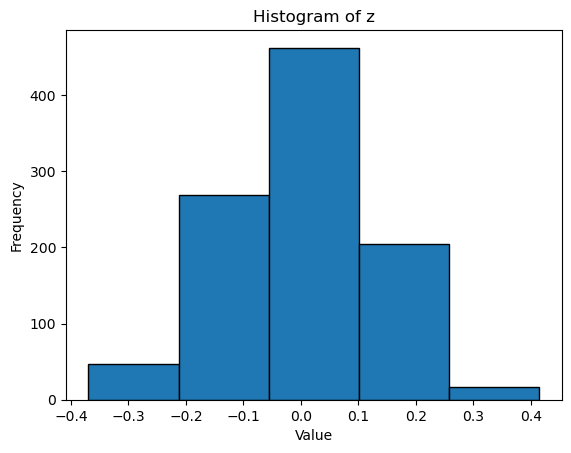

In [27]:
import matplotlib.pyplot as plt

plt.hist(z, bins=5, edgecolor='black')
plt.title('Histogram of z')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [31]:
fig = plt.gcf()
fig.canvas.draw()
plt.show()


<Figure size 640x480 with 0 Axes>

In [39]:
def _ensure_numpy(data):
    """Convert tensor to numpy array if needed."""
    if hasattr(data, 'detach'):
        return data.detach().cpu().numpy()
    return np.array(data) if not isinstance(data, np.ndarray) else data



In [ ]:
import torch.nn as nn
import torch
huber = nn.HuberLoss(delta=1.0, reduction='none')
mse = nn.MSELoss(reduction='none')
x = torch.randn(64, 345)
y = torch.randn(64, 345)
loss = mse(x, y)
loss.shape


torch.Size([])

In [ ]:
model.policy.features_extractor.extractors.pixels

NatureCNN(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (linear): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
  )
)

In [ ]:
print(f"Logger type: {type(model.logger)}")

# If it's a standard SB3 logger, you can check its attributes
if hasattr(model.logger, 'name_to_value'):
    print("Logged fields:")
    for key in model.logger.name_to_value.keys():
        print(f"- {key}")

Logger type: <class 'stable_baselines3.common.logger.Logger'>
Logged fields:
- train/learning_rate
- train/rnd_reward
- train/progress_reward
- train/surprisal_reward
- train/icm_reward
- train/disagreement_reward
- train/task_progress_reward
- train/entropy_loss
- train/policy_gradient_loss
- train/value_loss
- train/approx_kl
- train/clip_fraction
- train/loss
- train/explained_variance
- train/intrinsic_reward
- train/task_reward
- train/progress_wm_loss
- train/progress_trailing_wm_loss
- train/persistence_wm_loss
- train/persistence_trailing_wm_loss
- train/action_std
- train/action_mean
- train/passive_fraction
- train/state_switches
- train/std
- train/n_updates
- train/clip_range


In [ ]:
# env.observation_space

In [ ]:
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv, SubprocVecEnv, VecTransposeImage
from stable_baselines3.common.env_util import make_vec_env



In [ ]:
from dm_control import suite

vec_env = make_vec_env(lambda: swimmer(force_magnitude=0), n_envs=3, seed=1, monitor_dir=None, vec_env_cls=DummyVecEnv)


/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/home/rdkeller/miniconda3/envs/fishies/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and

NameError: name 'swimmer' is not defined

In [ ]:
vec_env.observation_space

Dict('pixels': Box(0, 255, (64, 64, 3), uint8), 'proprio': Box(-inf, inf, (25,), float64))

In [ ]:
venv = VecNormalize(VecTransposeImage(vec_env))

In [ ]:
venv.observation_space

Dict('pixels': Box(-10.0, 10.0, (3, 64, 64), float32), 'proprio': Box(-inf, inf, (25,), float64))

In [ ]:
venv2 = swimmer_venv(0, 0, 3, 1, None, 2, 0, True)

2025-02-17 22:54:04,411 - zfa_rl_agent.core.utils.logger - INFO - Vectorizing with DummyVecEnv
INFO:zfa_rl_agent.core.utils.logger:Vectorizing with DummyVecEnv


In [ ]:
venv2.observation_space

Dict('pixels': Box(-10.0, 10.0, (3, 64, 64), float32), 'proprio': Box(-inf, inf, (25,), float64))

In [ ]:
eval_env = make_vec_env(lambda: swimmer(force_magnitude=0), n_envs=1, seed=1, monitor_dir=None, vec_env_cls=DummyVecEnv)
eval_env = VecNormalize(VecTransposeImage(eval_env))

In [ ]:
from stable_baselines3.common.callbacks import EvalCallback

In [ ]:
eval_callback = EvalCallback(eval_env, eval_freq=1000, best_model_save_path=None)

In [ ]:
model = rPPO("MultiModalPolicy", venv, verbose=1)


Using cpu device


In [ ]:
model.policy

RnnMultiModalActorCriticPolicy(
  (features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (pixels): NatureCNN(
        (cnn): Sequential(
          (0): Conv2d(3, 32, kernel_size=(8, 8), stride=(4, 4))
          (1): ReLU()
          (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
          (3): ReLU()
          (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
          (5): ReLU()
          (6): Flatten(start_dim=1, end_dim=-1)
        )
        (linear): Sequential(
          (0): Linear(in_features=1024, out_features=256, bias=True)
          (1): ReLU()
        )
      )
      (proprio): MLP(
        (mlp): Sequential(
          (0): Linear(in_features=25, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
        )
      )
    )
  )
  (pi_features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (pixels): NatureCNN(
        (cnn): Sequential(
          (0): Conv2d(3

In [ ]:
model.learn(10000, callback=eval_callback)

----------------------------
| time/              |     |
|    fps             | 55  |
|    iterations      | 1   |
|    time_elapsed    | 6   |
|    total_timesteps | 384 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 37          |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 768         |
| train/                  |             |
|    approx_kl            | 0.007336918 |
|    clip_fraction        | 0.037       |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.1        |
|    explained_variance   | -0.0935     |
|    learning_rate        | 0.0003      |
|    loss                 | 1.15        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.016      |
|    value_loss           | 1.11        |
-----------------------------------------
-----------------------------------------